# S&P 500 Options: Feature Evaluation

Consolidated evaluation of Ch8 financial features (47) and Ch9 temporal features
(4) against short straddle return labels. Produces a diagnostic triage ledger;
downstream model notebooks do not consume it programmatically.

**Learning Objectives**:
- Evaluate feature predictive power via cross-sectional IC with HAC adjustment
- Apply Benjamini-Hochberg FDR correction across the 51 candidate features
- Compare IC sensitivity across hold-to-expiry and delta-hedged labels
- Assess feature redundancy via correlation analysis and family-level aggregation
- Produce a triage ledger categorizing features as PROCEED / REVISE / STOP

**Book Reference**: Chapter 8, Section 8.6 (Feature Evaluation)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) (financial features) and [`04_model_based_features`](04_model_based_features.ipynb) (temporal features)

**Evaluation Mode**: **Cross-sectional**, using daily rank IC within each
validation date and HAC inference across the resulting time series.

In [1]:
"""Feature Evaluation - S&P 500 Options.

Consolidated evaluation of Ch8 financial features and Ch9 temporal features
against forward return labels. Produces a diagnostic triage ledger.
"""

import warnings
from datetime import date, datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

from utils import style
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import COLORS  # registers the ml4t Plotly template on import

warnings.filterwarnings("ignore")

In [2]:
# Production defaults (Papermill overrides for testing)
MAX_SYMBOLS = 0  # 0 = all symbols

In [3]:
CASE_STUDY_ID = "sp500_options"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"
HAC_MAXLAGS = 20  # Roughly 21 trading days from entry to the selected expiry
MIN_PERIODS = 30  # Conservative minimum cross-section for rank IC
IC_THRESHOLD = 0.01  # Weekly horizon, moderate threshold

# Meta columns in financial.parquet that are NOT predictive features
META_COLS = {
    "timestamp",
    "symbol",
    "instrument_id",
    "underlying_price",
    "instr_mid",
    "instr_bid",
    "instr_ask",
}

## 0. Load Artifacts & Build Evaluation Panel

We load Ch8 financial features, the fold-specific Ch9 temporal feature panel,
and two label variants. Temporal features must be selected from the estimator
assigned to each validation window: the final holdout estimator was trained
through 2020 and is never valid for feature screening in 2019 or 2020.

### Validation-Fold Alignment

The split library returns timestamp boundaries. Normalize them once so every
comparison below uses the notebook's daily date schema.

In [4]:
def _as_date(value: date | datetime) -> date:
    """Normalize pandas and Python boundary values to dates."""
    return value.date() if hasattr(value, "date") else value

Fold identity is part of the temporal-feature key. Null or repeated keys make
estimator provenance ambiguous and therefore fail before any feature values
enter the evaluation panel.

In [5]:
def _validate_temporal_keys(temporal: pl.DataFrame) -> None:
    """Reject incomplete or ambiguous fold-specific temporal keys."""
    required = {"timestamp", "symbol", "fold"}
    missing = required.difference(temporal.columns)
    if missing:
        raise ValueError(f"Temporal artifact is missing required columns: {sorted(missing)}")

    null_keys = temporal.select(
        pl.any_horizontal([pl.col(key).is_null() for key in sorted(required)]).sum()
    ).item()
    if null_keys:
        raise ValueError(f"Temporal artifact has {null_keys} rows with null alignment keys")

    duplicate_keys = (
        temporal.group_by(["timestamp", "symbol", "fold"]).len().filter(pl.col("len") > 1).height
    )
    if duplicate_keys:
        raise ValueError(f"Temporal artifact has {duplicate_keys} duplicate fold-specific keys")

For each canonical split, retain only rows generated by that split's estimator
and dated inside its own validation window. The holdout estimator (`fold=-1`)
is never eligible for this feature-selection notebook.

In [6]:
def build_validation_temporal_panel(
    temporal: pl.DataFrame,
    cv_folds: list[dict],
) -> pl.DataFrame:
    """Select exactly the out-of-sample temporal estimate for each validation row."""
    _validate_temporal_keys(temporal)

    selected = []
    for split in cv_folds:
        fold_id = int(split["fold"])
        train_end = _as_date(split["train_end"])
        val_start = _as_date(split["val_start"])
        val_end = _as_date(split["val_end"])
        if train_end >= val_start:
            raise ValueError(f"Fold {fold_id} training ends inside its validation window")

        fold_rows = temporal.filter(
            (pl.col("fold") == fold_id)
            & pl.col("timestamp").is_between(val_start, val_end, closed="both")
        )
        if fold_rows.is_empty():
            raise ValueError(
                f"Temporal artifact has no validation rows for fold {fold_id} "
                f"({val_start} through {val_end})"
            )
        selected.append(fold_rows)

    validation = pl.concat(selected).rename({"fold": "validation_fold"})
    duplicate_rows = validation.group_by(JOIN_COLS).len().filter(pl.col("len") > 1).height
    if duplicate_rows:
        raise ValueError(
            f"Validation temporal panel has {duplicate_rows} multiply assigned date-symbol keys"
        )
    if validation.filter(pl.col("validation_fold") == -1).height:
        raise ValueError("Holdout temporal estimates entered the validation panel")
    return validation

The primary label carries its actual calendar days to expiry. Use that row-level
endpoint to purge the tail of the final validation fold before selection.

In [7]:
def purge_labels_before_holdout(labels: pl.DataFrame, holdout_start: date) -> pl.DataFrame:
    """Keep labels whose option expiry is strictly before the sealed holdout."""
    if "dte_calendar" not in labels.columns:
        raise ValueError("Primary label artifact is missing dte_calendar")
    if labels["dte_calendar"].null_count():
        raise ValueError("Primary label artifact has null expiry horizons")
    return labels.with_columns(
        (pl.col(DATE_COL) + pl.duration(days=pl.col("dte_calendar"))).alias("_label_end")
    ).filter(pl.col("_label_end") < holdout_start)

In [8]:
# Load features
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")
temporal = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet")

# Load primary and secondary labels. setup.yaml declares the hold-to-expiry
# short-straddle return as primary and no modelled variants (labels.variants is
# empty); the delta-hedged 10-day return built in 02_labels is the secondary
# label used in Section 6 to separate volatility signal from directional exposure.
_setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
_primary_name = _setup["labels"]["primary"]
_secondary_name = "fwd_ret_dh_10d"
primary_label_df = pl.read_parquet(CASE_DIR / "labels" / f"{_primary_name}.parquet")
secondary_label_df = pl.read_parquet(CASE_DIR / "labels" / f"{_secondary_name}.parquet")

# Auto-detect label column names
primary_label_col = [
    c for c in primary_label_df.columns if c not in META_COLS and c != "instrument_id"
][0]
secondary_label_col = [
    c for c in secondary_label_df.columns if c not in META_COLS and c != "instrument_id"
][0]

print(f"Primary label: {primary_label_col}")
print(f"Secondary label: {secondary_label_col}")

Primary label: ret_to_expiry
Secondary label: fwd_ret_dh_10d


Generate the same fold boundaries and embargo used by the temporal-feature
notebook, then remove primary labels whose realized endpoint reaches holdout.

In [9]:
# Use the same canonical split generator and label embargo as the temporal
# feature notebook. Every statistic in this notebook - IC ranking, HAC
# significance, BH-FDR discovery, and the PROCEED/STOP triage - is a feature-
# selection input for Ch11, so it is sealed to the pre-holdout CV window
# [START, holdout_start). The 2021 holdout is never touched here and stays
# unbiased for the final model assessment downstream.
cv_folds = generate_cv_splits(
    features.select(DATE_COL),
    case_study_id=CASE_STUDY_ID,
    label_buffer=str(_setup["labels"]["buffer"]),
)
evaluation_config = load_evaluation_config(CASE_STUDY_ID)
HOLDOUT_START = pl.Series([str(evaluation_config["holdout_start"])]).str.to_date().item()
temporal = build_validation_temporal_panel(temporal, cv_folds)

# The primary outcome is known only at option expiry. Purge rows whose actual
# label endpoint reaches the 2021 holdout, even when the feature timestamp is
# still in 2020. This keeps holdout prices out of IC, FDR, and triage decisions.
primary_selection_df = purge_labels_before_holdout(primary_label_df, HOLDOUT_START)

In [10]:
# Identify feature columns by source
financial_cols = [c for c in features.columns if c not in META_COLS]
temporal_cols = [c for c in temporal.columns if c not in JOIN_COLS + ["validation_fold"]]

# Build one validation-only evaluation panel. The one-to-one inner join excludes
# feature rows without a valid out-of-sample temporal estimate and rejects any
# duplicate alignment key instead of silently multiplying observations.
# Join the primary label only; the secondary
# delta-hedged label is joined separately in Section 6 so it never restricts
# the primary evaluation universe).
eval_panel = features.join(temporal, on=JOIN_COLS, how="inner", validate="1:1")
eval_panel = eval_panel.join(
    primary_selection_df.select(JOIN_COLS + [primary_label_col, "_label_end"]),
    on=JOIN_COLS,
    how="inner",
    validate="1:1",
)

null_temporal = eval_panel.select(
    pl.any_horizontal([pl.col(col).is_null() for col in temporal_cols]).sum()
).item()
if null_temporal:
    raise ValueError(f"Evaluation panel has {null_temporal} rows with null temporal features")

# Seal the holdout: the exact expiry endpoint, rather than only the feature date,
# must precede the holdout. The endpoint is no longer a predictive input.
if eval_panel.filter(pl.col("_label_end") >= HOLDOUT_START).height:
    raise ValueError("A primary label endpoint reaches the sealed holdout")
eval_panel = eval_panel.drop("_label_end")

all_feature_cols = financial_cols + temporal_cols

The production review uses the complete validation universe. `MAX_SYMBOLS`
remains a Papermill parameter for smoke tests only.

In [11]:
# Optional: reduce universe for fast dev
if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("symbol").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(top["symbol"]))

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
print(
    f"Eval panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates} dates "
    f"(sealed to < {HOLDOUT_START})"
)
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} temporal = {len(all_feature_cols)} total"
)
print(f"Date range: {eval_panel[DATE_COL].min()} to {eval_panel[DATE_COL].max()}")

Eval panel: 129,446 rows, 486 symbols, 484 dates (sealed to < 2021-01-01)
Features: 47 financial + 4 temporal = 51 total
Date range: 2019-01-07 to 2020-12-04


### Fold-Constant Feature Detection

A fold-fitted feature can be constant within a symbol's validation window yet
still vary across symbols. Detect that structure explicitly before applying
the usual staleness and IC interpretation.

In [12]:
fold_constant_features = set()
for feat in temporal_cols:
    unique_per_sym = eval_panel.group_by("symbol").agg(
        pl.col(feat).drop_nulls().n_unique().alias("n_unique")
    )["n_unique"]
    if unique_per_sym.mean() <= 3:
        fold_constant_features.add(feat)

if fold_constant_features:
    print(
        f"Fold-constant features ({len(fold_constant_features)}): {sorted(fold_constant_features)}"
    )
else:
    print("No fold-constant features detected")

No fold-constant features detected


## 1. Correctness Screens

Before evaluating predictive power, we check feature coverage (fraction non-null)
and staleness (fraction of dates where the value is unchanged). Features below
70% coverage or above 50% staleness are flagged.

In [13]:
coverage = {}
staleness = {}

for feat in all_feature_cols:
    n_valid = eval_panel[feat].drop_nulls().len()
    coverage[feat] = n_valid / n_rows

    # Staleness: fraction of dates where value unchanged from prior date (per symbol)
    df_sorted = eval_panel.select(JOIN_COLS + [feat]).sort(JOIN_COLS)
    unchanged = df_sorted.with_columns(
        (pl.col(feat) == pl.col(feat).shift(1).over("symbol")).alias("_same")
    )["_same"].sum()
    staleness[feat] = float(unchanged) / max(n_rows - n_symbols, 1)

# Correctness gate
correctness = {}
for feat in all_feature_cols:
    cov_ok = coverage[feat] >= 0.70
    stale_ok = staleness[feat] <= 0.50
    correctness[feat] = cov_ok and stale_ok

n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL out of {len(all_feature_cols)}")

Correctness gate: 49 PASS, 2 FAIL out of 51


In [14]:
if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [round(coverage[f], 3) for f, ok in correctness.items() if not ok],
            "staleness": [round(staleness[f], 3) for f, ok in correctness.items() if not ok],
        }
    )
    print("Failed correctness gate:")
    print(fail_df)

Failed correctness gate:
shape: (2, 3)
┌─────────────────────┬──────────┬───────────┐
│ feature             ┆ coverage ┆ staleness │
│ ---                 ┆ ---      ┆ ---       │
│ str                 ┆ f64      ┆ f64       │
╞═════════════════════╪══════════╪═══════════╡
│ qc_both_converged   ┆ 1.0      ┆ 1.0       │
│ qc_any_estimated_iv ┆ 1.0      ┆ 1.0       │
└─────────────────────┴──────────┴───────────┘


## 2. Univariate Association (Cross-Sectional IC + HAC)

For each feature that passes correctness, we compute:
- **IC time series**: daily cross-sectional Spearman rank correlation with the label
- **HAC-adjusted t-statistics**: Newey-West standard errors with bandwidth = 20
  (matching the roughly 21-trading-day hold-to-expiry horizon) to account for
  overlapping-return autocorrelation

Date-level features (identical across all symbols on a given date) produce zero
cross-sectional IC by construction and are flagged separately.

In [15]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

# Detect date-level features (zero cross-sectional variance)
cs_std_df = eval_panel.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Date-level features (zero CS variance): {sorted(date_level_features)}")

print(f"Evaluable features: {len(evaluable_features)}")

Evaluable features: 49


In [16]:
# Batch IC computation: group_by date, compute Spearman IC for all features
cs_features = [f for f in evaluable_features if f not in date_level_features]

# Filter to dates with enough observations
ts_counts = eval_panel.group_by(DATE_COL).len().filter(pl.col("len") >= MIN_PERIODS)
eval_sub = eval_panel.filter(pl.col(DATE_COL).is_in(ts_counts[DATE_COL]))

# Vectorized IC via Polars group_by + pl.corr
ic_wide = (
    eval_sub.group_by(DATE_COL)
    .agg(
        [pl.corr(f, primary_label_col, method="spearman").alias(f) for f in cs_features]
        + [pl.len().alias("n_obs")]
    )
    .sort(DATE_COL)
)

print(f"IC computed: {len(cs_features)} features × {len(ic_wide):,} dates")

IC computed: 49 features × 484 dates


In [17]:
# Compute HAC stats per feature
ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    ic_df = (
        ic_wide.select([DATE_COL, pl.col(feat).alias("ic"), "n_obs"])
        .drop_nulls(subset=["ic"])
        .filter(pl.col("ic").is_finite())
    )
    if len(ic_df) < 20:
        continue
    hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_results[feat] = hac_stats
    ic_timeseries[feat] = ic_df

print(f"HAC stats for {len(ic_results)} cross-sectional features")
print(f"Skipped {len(date_level_features)} date-level features")

HAC stats for 49 cross-sectional features
Skipped 0 date-level features


### Fold-Level Stability

Use the same canonical validation windows as the temporal-feature estimators
and check whether IC sign is consistent. Features with > 60% positive-IC
folds are more robust.

In [18]:
fold_stats = {}
for feat in ic_results:
    fold_ics = []
    ts = ic_timeseries[feat]
    for split in cv_folds:
        fold_start = _as_date(split["val_start"])
        fold_end = _as_date(split["val_end"])
        fold_ic = ts.filter(pl.col(DATE_COL).is_between(fold_start, fold_end, closed="both"))
        if len(fold_ic) >= 5:
            fold_ics.append(float(fold_ic["ic"].mean()))

    if fold_ics:
        sign_consistency = sum(1 for ic in fold_ics if ic > 0) / len(fold_ics)
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sign_consistency,
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
        }

n_consistent = sum(1 for s in fold_stats.values() if s["sign_consistency"] >= 0.6)
print(f"Fold stability: {n_consistent}/{len(fold_stats)} features with sign consistency >= 60%")

Fold stability: 14/49 features with sign consistency >= 60%


## 3. Multiple Testing (BH-FDR)

Testing 49 eligible features simultaneously at $\alpha = 0.05$ expects several false
positives. We apply the Benjamini-Hochberg procedure to control the false
discovery rate. The **inflation factor** measures how much naive significance
overstates true significance:

$$\text{Inflation} = \frac{N_{\text{naive significant}}}{N_{\text{FDR significant}}}$$

In [19]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

# Build evaluation summary table
eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": [float(p) for p in fdr_result["adjusted_p_values"]],
        "fdr_sig": [bool(r) for r in fdr_result["rejected"]],
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

Compare naive, overlap-adjusted, and multiple-testing-adjusted discovery counts.
When no feature survives FDR, the corresponding inflation ratio is undefined.

In [20]:
n_significant_naive = sum(
    1 for feature in feature_names if abs(ic_results[feature]["naive_t_stat"]) > 1.96
)
n_significant_hac = sum(1 for p_value in p_values if p_value < 0.05)
n_significant_fdr = int(fdr_result["n_rejected"])

inflation_hac = n_significant_naive / max(n_significant_hac, 1)
inflation_fdr = n_significant_naive / n_significant_fdr if n_significant_fdr else float("inf")

print(f"Features tested: {len(feature_names)}")
print(f"Naive significant (|t| > 1.96): {n_significant_naive}")
print(f"HAC significant (p < 0.05):     {n_significant_hac}")
print(f"FDR significant (q < 0.05):   {n_significant_fdr}")
print(f"Inflation factor (HAC): {inflation_hac:.2f}x")
if np.isfinite(inflation_fdr):
    print(f"Inflation factor (FDR): {inflation_fdr:.2f}x")
else:
    print("Inflation factor (FDR): undefined because no feature survives FDR")

Features tested: 49
Naive significant (|t| > 1.96): 9
HAC significant (p < 0.05):     3
FDR significant (q < 0.05):   0
Inflation factor (HAC): 3.00x
Inflation factor (FDR): undefined because no feature survives FDR


### IC Bar Chart + HAC Scatter

In [21]:
top_n = min(15, len(eval_summary))
top = eval_summary.head(top_n).sort("ic_mean")

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Largest absolute IC estimates",
        "Overlap correction shrinks naive t-statistics",
    ],
    horizontal_spacing=0.16,
)

# Panel 1: horizontal IC bars keep feature names legible.
colors = [
    COLORS["positive"]
    if p < 0.05 and ic > 0
    else COLORS["copper"]
    if p < 0.05
    else COLORS["silver_muted"]
    for p, ic in zip(top["hac_p"].to_list(), top["ic_mean"].to_list(), strict=True)
]
_ = fig.add_trace(
    go.Bar(
        x=top["ic_mean"].to_list(),
        y=top["feature"].to_list(),
        orientation="h",
        marker_color=colors,
        showlegend=False,
    ),
    row=1,
    col=1,
)

The right panel distinguishes individual HAC significance from the stricter
family-wide FDR decision.

In [22]:
# Panel 2: distinguish individual HAC significance from the FDR decision.
for is_hac_sig, label, color in [
    (False, "HAC p >= 0.05", COLORS["silver_muted"]),
    (True, "HAC p < 0.05", COLORS["positive"]),
]:
    subset = eval_summary.filter((pl.col("hac_p") < 0.05) == is_hac_sig)
    fig.add_trace(
        go.Scatter(
            x=subset["naive_t"].to_list(),
            y=subset["hac_t"].to_list(),
            mode="markers",
            marker=dict(color=color, size=8),
            text=subset["feature"].to_list(),
            name=label,
        ),
        row=1,
        col=2,
    )

The 45-degree line shows how far overlap-aware inference moves each naive
t-statistic. Titles and legends report the two discovery thresholds separately.

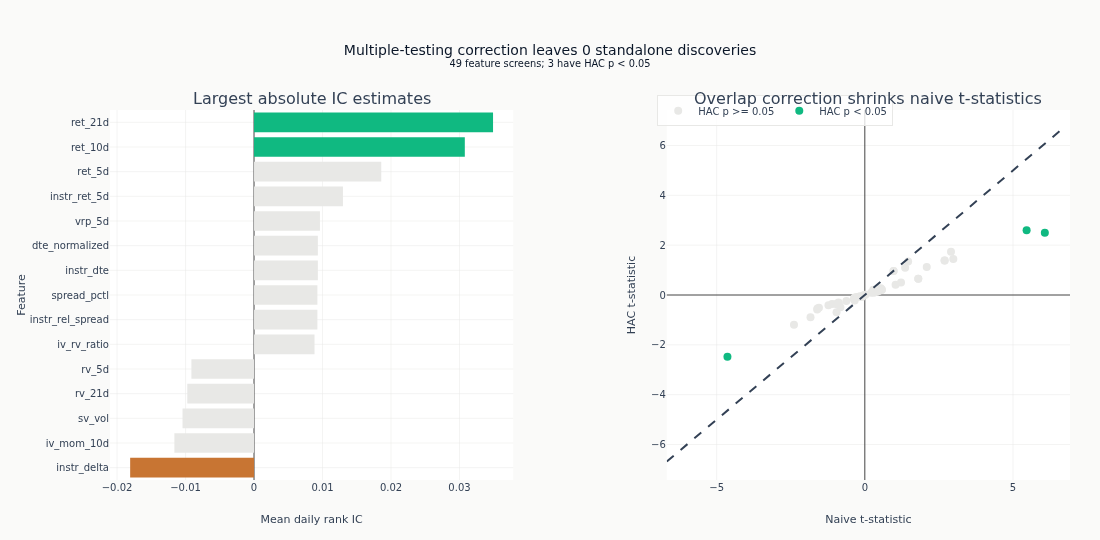

In [23]:
# 45-degree reference line
max_t = (
    max(
        float(eval_summary["naive_t"].abs().max() or 1.0),
        float(eval_summary["hac_t"].abs().max() or 1.0),
    )
    * 1.1
)
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color=COLORS["neutral"]),
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.update_layout(
    template="ml4t",
    height=540,
    width=1100,
    title={
        "text": (
            f"Multiple-testing correction leaves {n_significant_fdr} standalone discoveries"
            f"<br><sup>{len(feature_names)} feature screens; {n_significant_hac} have HAC p < 0.05</sup>"
        )
    },
    margin=dict(l=110, r=30, t=110, b=60),
    legend=dict(orientation="h", y=1.04, x=0.57),
)
fig.update_xaxes(title_text="Mean daily rank IC", zeroline=True, row=1, col=1)
fig.update_xaxes(title_text="Naive t-statistic", row=1, col=2)
fig.update_yaxes(title_text="Feature", row=1, col=1)
fig.update_yaxes(title_text="HAC t-statistic", row=1, col=2)
fig.show()

**Interpretation**: Points below the diagonal in the right panel show where
HAC adjustment deflates naive t-statistics. With overlapping hold-to-expiry
returns, daily IC values are autocorrelated and naive standard errors understate
uncertainty. A small set remains individually significant under HAC, but none
survives correction across all feature screens. PROCEED therefore means a
candidate for multivariate modeling, not a confirmed standalone signal.

## 4. Shape Diagnostics

Quantile monotonicity analysis: does the label spread monotonically across
feature quintiles? Monotone relationships are more likely to be real and
exploitable by linear models.

In [24]:
N_QUANTILES = 5
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:15]
if not top_features_for_shape:
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}

for feat in top_features_for_shape:
    valid = eval_panel.select([DATE_COL, feat, primary_label_col]).drop_nulls()
    if len(valid) < N_QUANTILES * 20:
        continue

    valid = valid.with_columns(
        ((pl.col(feat).rank("average").over(DATE_COL) - 1) * N_QUANTILES / pl.len().over(DATE_COL))
        .floor()
        .clip(0, N_QUANTILES - 1)
        .cast(pl.Int8)
        .alias("quantile_id")
    ).with_columns((pl.lit("Q") + (pl.col("quantile_id") + 1).cast(pl.String)).alias("quantile"))

    q_means = valid.group_by("quantile").agg(pl.col(primary_label_col).mean()).sort("quantile")
    means = q_means[primary_label_col].to_list()
    spread = means[-1] - means[0]
    quantile_spreads[feat] = {"q_means": means, "spread": spread}

    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

n_monotone = sum(1 for s in monotonicity_scores.values() if abs(s) >= 0.8)
print(
    f"Quantile analysis: {n_monotone}/{len(monotonicity_scores)} features with monotonicity >= 0.8"
)

Quantile analysis: 3/10 features with monotonicity >= 0.8


### Quantile Return Plots

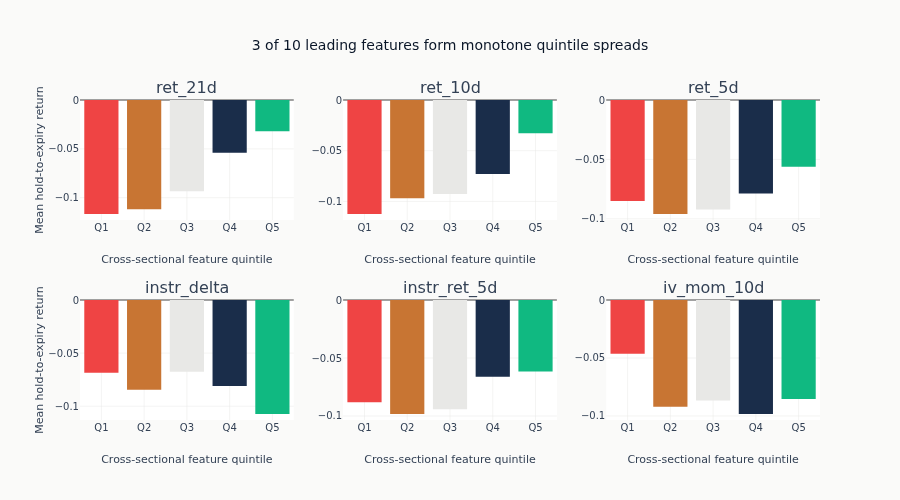

In [25]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    n_cols = min(3, n_show)
    n_rows_fig = (n_show + n_cols - 1) // n_cols

    fig = make_subplots(rows=n_rows_fig, cols=n_cols, subplot_titles=feats_to_show[:n_show])
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, n_cols)
        q_means = quantile_spreads[feat]["q_means"]
        fig.add_trace(
            go.Bar(
                x=[f"Q{i + 1}" for i in range(len(q_means))],
                y=q_means,
                marker_color=[
                    COLORS["negative"],
                    COLORS["copper"],
                    COLORS["silver_muted"],
                    COLORS["slate"],
                    COLORS["positive"],
                ],
                showlegend=False,
            ),
            row=r + 1,
            col=c + 1,
        )
    fig.update_layout(
        template="ml4t",
        height=250 * n_rows_fig,
        width=900,
        title_text=(
            f"{n_monotone} of {len(monotonicity_scores)} leading features form monotone "
            "quintile spreads"
        ),
    )
    fig.update_xaxes(title_text="Cross-sectional feature quintile")
    for row in range(1, n_rows_fig + 1):
        fig.update_yaxes(title_text="Mean hold-to-expiry return", row=row, col=1)
    fig.show()

## 5. Redundancy & Feature Families

Pairwise correlation matrix and family-level IC aggregation.
High within-family correlation is expected (e.g., VRP features at different
horizons); high between-family correlation signals redundancy that Ch11
should address.

### Feature Family Assignment

In [26]:
FEATURE_FAMILY_PATTERNS = [
    (
        [
            "instr_rel_spread",
            "instr_pct_of_S",
            "instr_dte",
            "dte_",
            "instr_delta",
            "abs_net_delta",
            "instr_gamma",
            "instr_theta",
            "instr_vega",
            "theta_vega_ratio",
            "instr_ret_",
            "instr_cost_",
        ],
        "instrument_state",
    ),
    (["iv_atm", "call_iv", "put_iv", "iv_skew", "iv_atm_z_", "iv_mom_"], "surface"),
    (["vrp_", "iv_rv_ratio"], "vrp"),
    (["rv_"], "realized_vol"),
    (["_pctl"], "cross_sectional"),
    (["ret_1d", "ret_5d", "ret_10d", "ret_21d", "volume_zscore"], "underlying"),
    (["qc_"], "quality"),
    (["garch_"], "temporal_garch"),
    (["sv_"], "temporal_sv"),
]

Match in order so specific instrument and volatility-risk-premium prefixes
take precedence over the generic fallback.

In [27]:
def assign_feature_family(feature_name: str) -> str:
    """Map a feature name to its S&P 500 options family."""
    name_lower = feature_name.lower()
    for prefixes, family in FEATURE_FAMILY_PATTERNS:
        if any(p in name_lower for p in prefixes):
            return family
    return "other"


families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

family_counts = {}
for fam in families.values():
    family_counts[fam] = family_counts.get(fam, 0) + 1
for fam, count in sorted(family_counts.items(), key=lambda x: -x[1]):
    print(f"  {fam:25s}: {count} features")

  instrument_state         : 12 features
  vrp                      : 11 features
  surface                  : 10 features
  realized_vol             : 5 features
  underlying               : 5 features
  quality                  : 2 features
  temporal_garch           : 2 features
  temporal_sv              : 2 features
  other                    : 1 features
  cross_sectional          : 1 features


### Correlation Analysis

In [28]:
# Pairwise Spearman correlation on evaluable features (sample dates for speed)
corr_features = [f for f in evaluable_features if f in ic_results]
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = (
    eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(corr_features).to_pandas()
)
corr_matrix = corr_data.corr(method="spearman")

high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((cols[i], cols[j], round(corr_matrix.iloc[i, j], 3)))

print(f"Feature pairs with |corr| > 0.7: {len(high_corr_pairs)}")
if high_corr_pairs:
    for f1, f2, c in sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:10]:
        print(f"  {f1:30s} -- {f2:30s}: {c:+.3f}")

Feature pairs with |corr| > 0.7: 86
  instr_dte                      -- dte_normalized                : +1.000
  iv_atm                         -- call_iv                       : +0.999
  iv_atm                         -- put_iv                        : +0.999
  call_iv                        -- put_iv                        : +0.994
  instr_gamma                    -- instr_theta                   : +0.993
  instr_pct_of_S                 -- iv_atm                        : +0.992
  instr_pct_of_S                 -- call_iv                       : +0.991
  instr_pct_of_S                 -- put_iv                        : +0.990
  theta_vega_ratio               -- iv_atm                        : -0.973
  vrp_21d                        -- iv_rv_ratio                   : +0.973


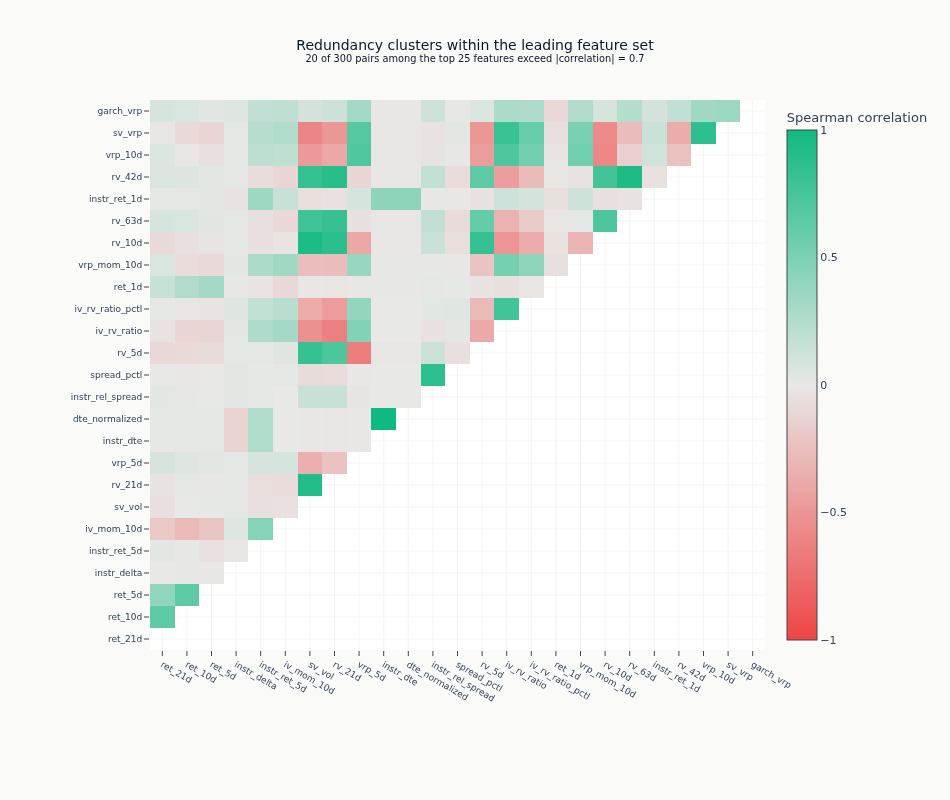

In [29]:
# Diverging colorscale sourced from the ML4T palette (negative -> neutral -> positive)
_div = style.ml4t_diverging()
ml4t_corr_scale = [[0.0, _div[0]], [0.5, _div[1]], [1.0, _div[2]]]
corr_plot_features = eval_summary.head(min(25, len(eval_summary)))["feature"].to_list()
corr_plot = corr_matrix.loc[corr_plot_features, corr_plot_features]
corr_display = corr_plot.mask(np.triu(np.ones(corr_plot.shape, dtype=bool)))
corr_plot_pairs = sum(
    abs(corr_plot.iloc[i, j]) > 0.7
    for i in range(len(corr_plot.columns))
    for j in range(i + 1, len(corr_plot.columns))
)
fig = go.Figure(
    data=go.Heatmap(
        z=corr_display.values,
        x=corr_plot.columns.tolist(),
        y=corr_plot.columns.tolist(),
        colorscale=ml4t_corr_scale,
        zmid=0,
        zmin=-1,
        zmax=1,
        colorbar=dict(title="Spearman correlation"),
    )
)
fig.update_layout(
    title={
        "text": (
            "Redundancy clusters within the leading feature set"
            f"<br><sup>{corr_plot_pairs} of {len(corr_plot_features) * (len(corr_plot_features) - 1) // 2} "
            f"pairs among the top {len(corr_plot_features)} features exceed |correlation| = 0.7</sup>"
        )
    },
    template="ml4t",
    height=800,
    width=950,
    margin=dict(l=150, r=50, t=100, b=150),
)
fig.update_xaxes(tickfont=dict(size=9))
fig.update_yaxes(tickfont=dict(size=9))
fig.show()

### Family-Level IC Summary

In [30]:
family_ic = {}
fdr_sig_set = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())

for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {"feature": feat, "ic": ic_results[feat]["mean_ic"], "fdr_sig": feat in fdr_sig_set}
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
    print(fam_df)
else:
    fam_df = pl.DataFrame()
    print("No features passed IC evaluation threshold")

shape: (9, 5)
┌──────────────────┬────────────┬────────────┬───────────┬───────────┐
│ family           ┆ n_features ┆ avg_abs_ic ┆ avg_ic    ┆ n_fdr_sig │
│ ---              ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ str              ┆ i64        ┆ f64        ┆ f64       ┆ i64       │
╞══════════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ underlying       ┆ 5          ┆ 0.018536   ┆ 0.018384  ┆ 0         │
│ cross_sectional  ┆ 1          ┆ 0.009253   ┆ 0.009253  ┆ 0         │
│ temporal_sv      ┆ 2          ┆ 0.007907   ┆ -0.002537 ┆ 0         │
│ realized_vol     ┆ 5          ┆ 0.007885   ┆ -0.007885 ┆ 0         │
│ instrument_state ┆ 12         ┆ 0.006387   ┆ 0.003305  ┆ 0         │
│ vrp              ┆ 11         ┆ 0.005321   ┆ 0.001694  ┆ 0         │
│ surface          ┆ 10         ┆ 0.002807   ┆ -0.002592 ┆ 0         │
│ temporal_garch   ┆ 2          ┆ 0.002701   ┆ -0.002701 ┆ 0         │
│ other            ┆ 1          ┆ 0.000041   ┆ -0.000041 ┆ 0   

## 6. Secondary Delta-Hedged Label Check

The secondary label applies daily delta hedging over 10 days, while the primary
label is an unhedged hold-to-expiry outcome of roughly 21 trading days. Because
both hedge treatment and horizon change, this is a sensitivity check rather
than an attribution of the difference to directional exposure alone.

In [31]:
# Join the delta-hedged label onto the sealed evaluation panel (inner join here
# so the comparison uses only rows where the hedged label exists, without
# restricting the primary evaluation above).
dh_eval = eval_sub.join(
    secondary_label_df.select(JOIN_COLS + [secondary_label_col]),
    on=JOIN_COLS,
    how="inner",
)

# Compute IC against delta-hedged label
dh_ic_wide = (
    dh_eval.group_by(DATE_COL)
    .agg([pl.corr(f, secondary_label_col, method="spearman").alias(f) for f in cs_features])
    .sort(DATE_COL)
)

dh_ic_results = {}
for feat in cs_features:
    ic_df = (
        dh_ic_wide.select([DATE_COL, pl.col(feat).alias("ic")])
        .drop_nulls(subset=["ic"])
        .filter(pl.col("ic").is_finite())
    )
    if len(ic_df) < 20:
        continue
    dh_ic_results[feat] = float(ic_df["ic"].mean())

Plot every eligible feature against the two outcome definitions. Label the
momentum horizons and option delta because they anchor the interpretation.

In [32]:
# Compare unhedged vs delta-hedged IC
dh_rows = []
for feat in cs_features:
    if feat in ic_results and feat in dh_ic_results:
        dh_rows.append(
            {
                "feature": feat,
                "ic_unhedged": round(ic_results[feat]["mean_ic"], 4),
                "ic_hedged": round(dh_ic_results[feat], 4),
            }
        )

if dh_rows:
    dh_df = pl.DataFrame(dh_rows).sort(pl.col("ic_unhedged").abs(), descending=True)
    highlighted = ["ret_5d", "ret_10d", "ret_21d", "instr_delta"]
    background = dh_df.filter(~pl.col("feature").is_in(highlighted))
    foreground = dh_df.filter(pl.col("feature").is_in(highlighted))

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=background["ic_unhedged"].to_list(),
            y=background["ic_hedged"].to_list(),
            mode="markers",
            marker=dict(color=COLORS["silver_muted"], size=7),
            text=background["feature"].to_list(),
            name="Other features",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=foreground["ic_unhedged"].to_list(),
            y=foreground["ic_hedged"].to_list(),
            mode="markers+text",
            marker=dict(color=COLORS["positive"], size=9),
            text=foreground["feature"].to_list(),
            textposition="top center",
            name="Momentum and delta",
        )
    )

A common symmetric scale and 45-degree reference preserve the sign and
magnitude comparison without implying that the two horizons are equivalent.

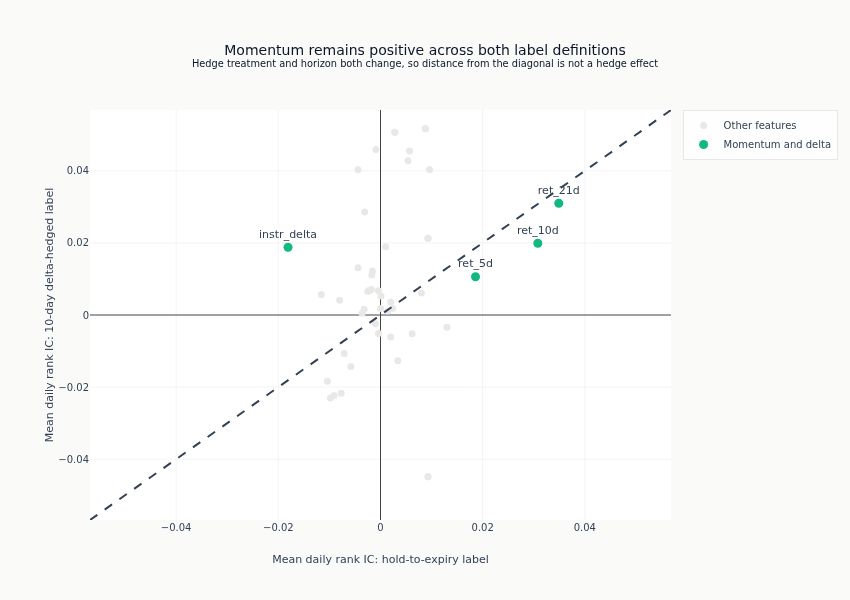

In [33]:
if dh_rows:
    label_limit = float(max(dh_df["ic_unhedged"].abs().max(), dh_df["ic_hedged"].abs().max()) * 1.1)
    fig.add_trace(
        go.Scatter(
            x=[-label_limit, label_limit],
            y=[-label_limit, label_limit],
            mode="lines",
            line=dict(color=COLORS["neutral"], dash="dash"),
            showlegend=False,
        )
    )
    fig.update_layout(
        title={
            "text": (
                "Momentum remains positive across both label definitions"
                "<br><sup>Hedge treatment and horizon both change, so distance from the diagonal "
                "is not a hedge effect</sup>"
            )
        },
        template="ml4t",
        width=850,
        height=600,
        xaxis_title="Mean daily rank IC: hold-to-expiry label",
        yaxis_title="Mean daily rank IC: 10-day delta-hedged label",
        xaxis_range=[-label_limit, label_limit],
        yaxis_range=[-label_limit, label_limit],
        margin=dict(l=90, r=30, t=110, b=80),
    )
    fig.show()

**Interpretation**: The momentum features retain positive IC under both label
definitions, while option delta changes sign. This supports momentum as the more
stable association. The comparison cannot identify a hedge effect because the
secondary outcome also shortens the horizon.

## 7. Triage & Handoff

Apply triage rules to categorize features for Ch11 modeling:

| Decision | Criteria |
|----------|----------|
| **PROCEED** | FDR-significant at 5%, OR sign consistent across at least 60% of folds AND abs(IC) > 0.01 |
| **STOP** | Correctness FAIL (coverage < 70% OR staleness > 50%) |
| **REVISE** | Everything else (evaluate in multivariate context in Ch11) |

In [34]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat in date_level_features:
        triage[feat] = ("REVISE", "date_level_feature")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_set
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if feat in fold_constant_features:
        # Fold-constant features: still evaluate via CS-IC
        if is_fdr_sig:
            triage[feat] = ("PROCEED", "fdr_significant_fold_constant")
        else:
            triage[feat] = ("REVISE", "fold_constant")
    elif is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= 0.60 and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

### Build Triage Ledger

In [35]:
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = float(match["fdr_p"][0])
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print("Triage ledger saved: evaluation/triage_ledger.parquet")
print(triage_ledger.group_by("decision").len().sort("decision"))

Triage ledger saved: evaluation/triage_ledger.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 4   │
│ REVISE   ┆ 45  │
│ STOP     ┆ 2   │
└──────────┴─────┘


### Save IC Time Series

In [36]:
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"IC time series saved: evaluation/ic_timeseries.parquet ({len(ic_ts_all):,} rows)")

IC time series saved: evaluation/ic_timeseries.parquet (23,214 rows)


### Collect Triage Results

In [37]:
proceed_features = sorted(f for f, (d, _) in triage.items() if d == "PROCEED")
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

### Triage Summary

In [38]:
print(f"\n{'=' * 60}")
print(f"TRIAGE SUMMARY: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"  PROCEED: {len(proceed_features)} features")
print(f"  REVISE:  {len(revise_features)} features")
print(f"  STOP:    {len(stop_features)} features")
print("\nPROMOTED (PROCEED) features:")
for f in proceed_features:
    ic = ic_results[f]["mean_ic"]
    t = ic_results[f]["t_stat"]
    print(f"  {f:40s}  IC={ic:+.4f}  t={t:.2f}  [{families.get(f, '?')}]")

if stop_features:
    print("\nSTOPPED features:")
    for f in sorted(stop_features):
        print(f"  {f:40s}  [{triage[f][1]}]")


TRIAGE SUMMARY: sp500_options
  PROCEED: 4 features
  REVISE:  45 features
  STOP:    2 features

PROMOTED (PROCEED) features:
  instr_ret_5d                              IC=+0.0130  t=1.73  [instrument_state]
  ret_10d                                   IC=+0.0308  t=2.60  [underlying]
  ret_21d                                   IC=+0.0349  t=2.50  [underlying]
  ret_5d                                    IC=+0.0186  t=1.45  [underlying]

STOPPED features:
  qc_any_estimated_iv                       [correctness_fail]
  qc_both_converged                         [correctness_fail]


### Quality Gate Reading

The triage promotes 4 of 51 candidates to PROCEED: three underlying-momentum
horizons and the 5-day straddle return. The 10- and 21-day momentum features are
individually significant after 20-lag HAC adjustment, but none of the 49
evaluable features survives BH-FDR. All four promotions therefore reflect
stability across both validation folds rather than a standalone discovery.
The 486-symbol panel supports continued multivariate testing, not a claim that
any feature clears the strategy's implementation-cost hurdle by itself.

## Key Takeaways

1. **Cross-sectional IC is the primary metric**: With hundreds of symbols per
   date, cross-sectional rank correlation provides daily IC estimates. HAC
   adjustment (bandwidth = 20) accounts for the overlap in roughly
   21-trading-day hold-to-expiry outcomes.

2. **Momentum is the stable family**: The 5-, 10-, and 21-day underlying returns
   have positive IC in both validation folds. No feature survives FDR across the
   full screen, so PROCEED marks a diagnostic priority, not an accepted edge.

3. **The secondary label is a sensitivity check**: Momentum stays positive for
   the 10-day delta-hedged outcome, but hedge treatment and horizon both differ
   from the primary label. Their IC difference cannot be assigned to hedging.

4. **Economic viability remains downstream**: The screen measures association,
   not net returns. Ch16-18 determine whether a modeled signal survives option
   spreads, hedge trading, and portfolio constraints.

**Next**: Ch11 ([`06_linear`](06_linear.ipynb)) fits Ridge/Lasso models to the full
modeling feature panel and does not consume this ledger. Ch20
([`02_feature_evaluation`](../../20_strategy_synthesis/02_feature_evaluation.ipynb))
does consume it for nine-case feature-survival analysis. The current SP500 row
changes from the printed Table 20.3 values of 6 PROCEED, 4 FDR-significant, and
11.8% PROCEED to 4, 0, and 7.84%; this does not change model inputs or the registry.